# Prédiction du churn client et identification des profils à risque

## Contexte métier

Dans le secteur des télécommunications, le churn client représente un enjeu majeur, car la perte d’un client entraîne une baisse de revenus et un coût potentiel de remplacement élevé.

L’objectif de ce projet est de construire une solution de Data Science permettant :
- de prédire si un client risque de quitter l’entreprise ;
- d’identifier des profils de clients à risque afin d’orienter les stratégies de rétention.

## Présentation du dataset

Le dataset utilisé est le jeu de données Telco Customer Churn.  
Chaque ligne représente un client et chaque colonne décrit des informations démographiques, contractuelles, de services ou de facturation.

La variable cible est `Churn`, qui indique si le client a quitté l’entreprise ou non.

# Analyse exploratoire des données (EDA)

L’objectif de cette analyse est de comprendre la structure des données, identifier les variables importantes et détecter les facteurs potentiellement liés au churn client.

Cette étape est essentielle pour orienter le preprocessing et le choix des modèles de machine learning.

## 1. Chargement des données

Nous commençons par importer les bibliothèques nécessaires et charger le dataset.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/dataset.csv')

# Affichage des 5 premières lignes
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Structure des données

Cette étape permet d’identifier :
- le nombre d’observations et de variables ;
- les types de variables (numériques, catégorielles) ;
- la présence éventuelle de valeurs manquantes.

On remarque notamment que certaines variables numériques comme `TotalCharges` sont stockées comme des objets, ce qui nécessitera un traitement.

In [34]:
print(f"Dimensions du dataset : {df.shape}\n")

df.info()

Dimensions du dataset : (7043, 21)

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling 

## 4. Analyse descriptive

### Variables numériques

Les statistiques descriptives permettent d’avoir une première idée de la distribution des variables comme l’ancienneté (`tenure`) et les charges mensuelles (`MonthlyCharges`).

### Variable cible

La variable `Churn` indique si un client a quitté l’entreprise.
On observe la proportion de churn afin de vérifier si les classes sont équilibrées.

In [35]:
# Statistiques pour les variables numériques
display(df.describe())

# Pour voir la répartition de la variable cible
print("\nRépartition du Churn :")
display(df['Churn'].value_counts(normalize=True) * 100) # En pourcentage

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Répartition du Churn :


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

On observe un déséquilibre modéré : environ 27% des clients ont churné.
Ce point sera important pour le choix des métriques (le recall sera privilégié).

## 5. Nettoyage des données

La variable `TotalCharges` est actuellement au format texte et contient des valeurs vides.

Nous la convertissons en numérique, ce qui transforme les valeurs invalides en NaN, puis nous supprimons les lignes concernées.

In [36]:
# 1. Vérification avant nettoyage
print(" Valeurs manquantes explicites (NaN) ")
print(df.isnull().sum())


print("\nVérification des doublons")
print(f"Nombre de doublons : {df.duplicated().sum()}")

# 2. Nettoyage
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])
df = df.drop_duplicates()

# 3. Confirmation après nettoyage
print("\nNettoyage terminé")
print(f"Dimensions finales du dataset : {df.shape}")

 Valeurs manquantes explicites (NaN) 
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Vérification des doublons
Nombre de doublons : 0

Nettoyage terminé
Dimensions finales du dataset : (7032, 21)


Après conversion et suppression des lignes concernées, le dataset reste très proche de sa taille initiale, ce qui limite l’impact sur l’analyse."

## 6. Analyse des relations avec le churn

Nous analysons ici les variables les plus pertinentes en lien avec la variable cible.
L’objectif est d’identifier les facteurs pouvant expliquer le churn.

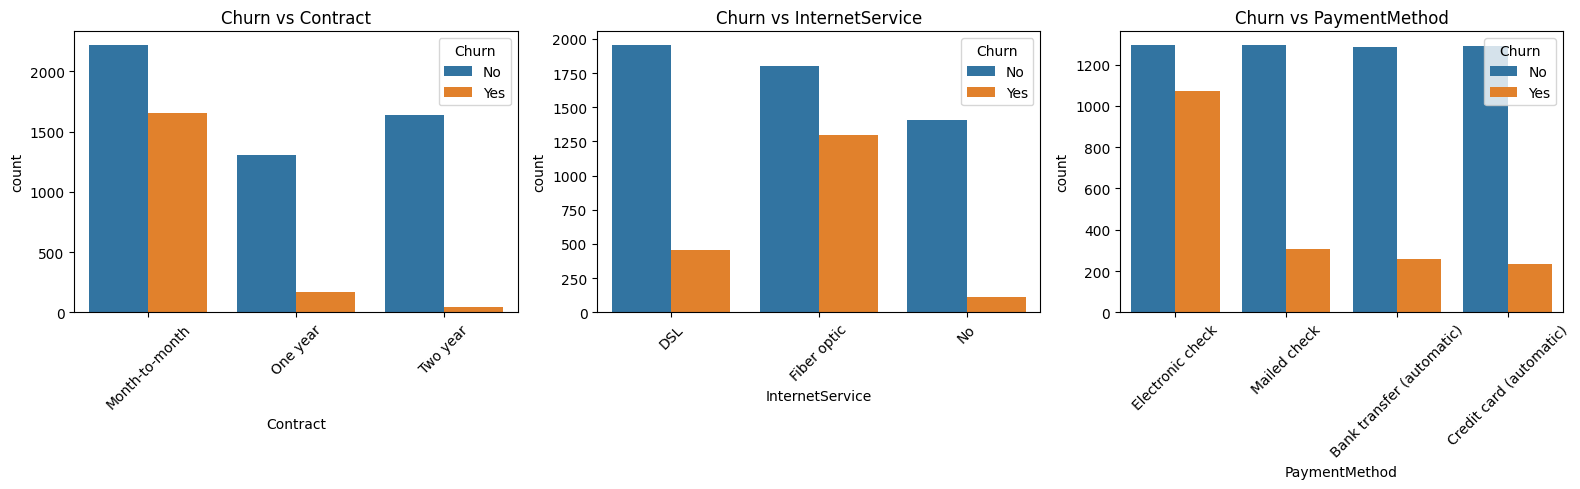

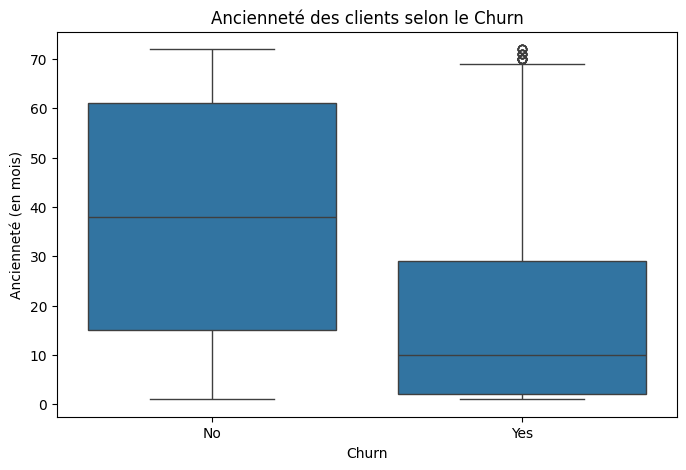

--- TAUX DE CHURN PAR CATÉGORIE (en %) ---

Répartition pour Contract :


Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85



Répartition pour InternetService :


Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43



Répartition pour PaymentMethod :


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Visualisations des variables clés
cols_to_plot = ['Contract', 'InternetService', 'PaymentMethod']

plt.figure(figsize=(16, 5))
for i, col in enumerate(cols_to_plot):
    plt.subplot(1, 3, i+1)
    sns.countplot(data=df, x=col, hue='Churn')
    plt.title(f'Churn vs {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Churn vs Ancienneté
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Ancienneté des clients selon le Churn')
plt.ylabel('Ancienneté (en mois)')
plt.show()

# 3. Analyse en %
print("--- TAUX DE CHURN PAR CATÉGORIE (en %) ---")
for col in cols_to_plot:
    print(f"\nRépartition pour {col} :")
    # On crée un tableau croisé dynamique converti en %
    analyse_pct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    display(analyse_pct.round(2))

**1. Impact du contrat et de l'engagement**

Les clients avec un contrat mensuel ("Month-to-month") churnent beaucoup plus que ceux engagés sur 1 ou 2 ans. L’engagement contractuel est le premier levier de fidélisation identifié.

**2. Profil technique et Services**

Service Internet : Les clients disposant de la Fibre optique présentent un taux de churn nettement plus élevé que ceux en DSL. Cela peut révéler une insatisfaction liée au prix ou à la stabilité du service fibre.

Ancienneté : Les clients qui partent ont en moyenne une ancienneté plus faible. Le risque de départ est maximal durant les premiers mois (problème d'onboarding).

**3. Comportement de paiement (Nouveau)**

Le mode de paiement par Electronic check est fortement corrélé au churn. Les clients utilisant des méthodes de paiement plus "automatiques" (carte bancaire, virement) sont plus stables.

## 7. Analyse des corrélations

La matrice de corrélation permet d’identifier les relations entre variables numériques.

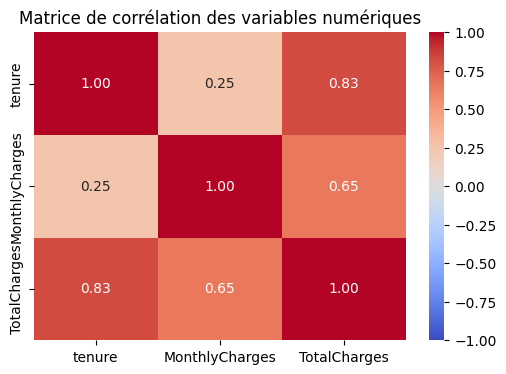

In [38]:
# Sélection des variables numériques
cols_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Calcul de la matrice de corrélation
corr_matrix = df[cols_num].corr()

# Affichage avec une Heatmap (carte de chaleur)
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matrice de corrélation des variables numériques')
plt.show()

**Analyse des corrélations**

On observe une forte corrélation (0.82) entre `tenure` et `TotalCharges`, ce qui est logique puisque les charges cumulées augmentent avec le temps passé chez l'opérateur.

*Note importante : La corrélation est ici calculée uniquement sur les variables numériques. Les variables catégorielles (comme le type d'abonnement ou de contrat) ne peuvent pas être intégrées directement dans cette matrice. Elles seront transformées en valeurs numériques lors de l'étape de preprocessing juste après.*

## 8. Conclusion de l’EDA

Cette analyse exploratoire met en évidence plusieurs éléments importants :

- les clients récents churnent davantage ;
- les contrats mensuels sont associés à un taux de churn plus élevé ;
- certaines variables comme les charges et l’ancienneté sont fortement liées entre elles.

Ces observations guideront les étapes suivantes :
- le preprocessing des données ;
- le choix des variables ;
- la modélisation supervisée et non supervisée.

## 9. Modélisation supervisée

L’objectif est de prédire si un client va churner à partir de ses caractéristiques.

Nous utilisons une pipeline incluant :
- le preprocessing (standardisation + encodage)
- un modèle de régression logistique

Cette approche permet de garantir la cohérence entre entraînement et prédiction.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Séparation Features (X) / Target (y)
X = df.drop(columns=['Churn', 'customerID'])
y = df['Churn']

# 2. Encodage de la Target (Exigence stricte de ton prof)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

### Séparation des données

Nous séparons les données en :
- ensemble d’entraînement (80%)
- ensemble de test (20%)

La stratification est utilisée pour conserver la proportion de churn dans les deux ensembles.

In [40]:
# 3. Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

### Pipeline de preprocessing

Nous appliquons :
- StandardScaler sur les variables numériques
- OneHotEncoder sur les variables catégorielles

Cela permet de préparer correctement les données pour le modèle.

### Évaluation du modèle

Nous évaluons les performances à l’aide des métriques :
- précision
- recall
- F1-score

Dans un contexte de churn, le recall est particulièrement important car il permet d’identifier un maximum de clients à risque.

MODÈLE 1 : RÉGRESSION LOGISTIQUE

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

No Churn (0)       0.85      0.88      0.87      1033
   Churn (1)       0.64      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.80      1407


Matrice de Confusion : Régression Logistique


/var/folders/nj/gnzs8lsd68xclw24myx2r5840000gn/T/ipykernel_35765/1086885974.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


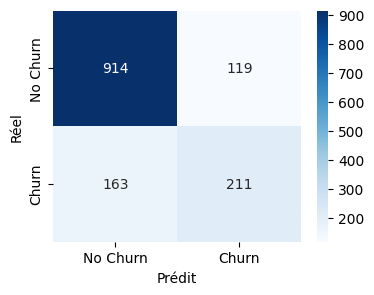


MODÈLE 2 : RANDOM FOREST

RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

No Churn (0)       0.82      0.89      0.86      1033
   Churn (1)       0.61      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407


Matrice de Confusion : Random Forest


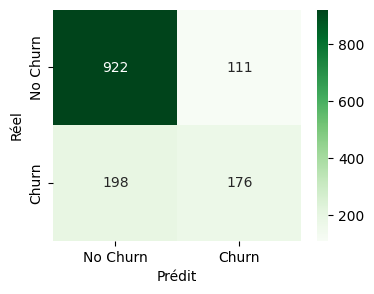

In [41]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# 4. Création du Preprocessor (identique à ce que tu as fait)
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ])
# MODÈLE 1 : RÉGRESSION LOGISTIQUE

print("="*50)
print("MODÈLE 1 : RÉGRESSION LOGISTIQUE")
print("="*50)

log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

log_pipeline.fit(X_train, y_train)
y_pred_log = log_pipeline.predict(X_test)

print("\nRAPPORT DE CLASSIFICATION")
print(classification_report(y_test, y_pred_log, target_names=['No Churn (0)', 'Churn (1)']))

print("\nMatrice de Confusion : Régression Logistique")
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(4,3))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# MODÈLE 2 : RANDOM FOREST
print("\n" + "="*50)
print("MODÈLE 2 : RANDOM FOREST")
print("="*50)

# On crée une 2ème pipeline pour le Random Forest !
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Entraînement et Prédiction
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("\nRAPPORT DE CLASSIFICATION")
print(classification_report(y_test, y_pred_rf, target_names=['No Churn (0)', 'Churn (1)']))

print("\nMatrice de Confusion : Random Forest")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(4,3))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

Le modèle atteint une accuracy de 80%, ce qui est correct.

Cependant, le recall sur la classe churn (56%) reste limité.
Cela signifie que le modèle ne détecte qu’un peu plus de la moitié des clients qui vont réellement partir.

Dans un contexte business, cela peut être problématique car certains clients à risque ne seront pas identifiés.

Des améliorations sont possibles :
- tester d’autres modèles (Random Forest, Gradient Boosting)
- ajuster les paramètres
- travailler sur l’équilibrage des classes

In [42]:
import joblib
import os

# Création du dossier models s'il n'existe pas
os.makedirs('models', exist_ok=True)

# Sauvegarde de la Pipeline complète (Preprocessing + Modèle)
joblib.dump(model_pipeline, 'models/model.pkl')

print("Modèle sauvegardé avec succès dans le dossier 'models/' !")

Modèle sauvegardé avec succès dans le dossier 'models/' !


## 10. Modélisation non supervisée (clustering)

L’objectif est de segmenter les clients en groupes homogènes afin de mieux comprendre les profils de churn.

Nous utilisons l’algorithme K-Means sur les variables numériques.

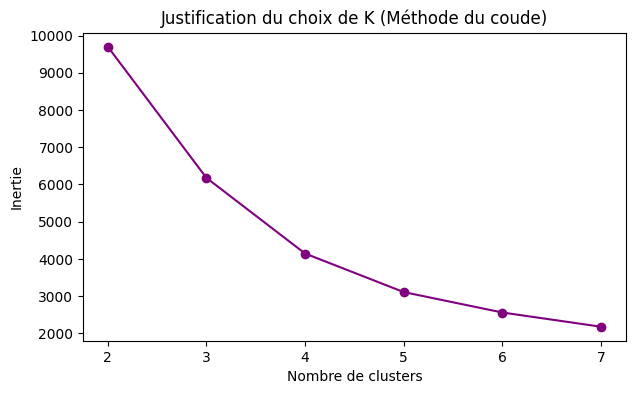

PROFIL DES CLUSTERS (SEGMENTATION)


,tenure,MonthlyCharges,TotalCharges,Nombre_Clients,Taux_Churn_Reel (%)
Cluster,,,,,
0,29.62,26.63,815.26,2151,12.32
1,58.57,89.74,5249.43,2197,15.38
2,13.26,74.97,1031.88,2684,47.17


In [43]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Préparation des données
X_num = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# 2. JUSTIFICATION : Méthode du coude
inertias = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, marker='o', color='purple')
plt.title("Justification du choix de K (Méthode du coude)")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.show()

# 3. CRÉATION DES GROUPES
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. ANALYSE BUSINESS
cluster_summary = df.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()
cluster_summary['Nombre_Clients'] = df['Cluster'].value_counts()
cluster_summary['Taux_Churn_Reel (%)'] = df.groupby('Cluster')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)

print("PROFIL DES CLUSTERS (SEGMENTATION)")
display(cluster_summary.round(2))

**Interprétation du Clustering :**

Méthode du coude : On observe un fléchissement de la courbe à 3 clusters, ce qui justifie notre choix.

Analyse des profils : >    - Le groupe avec le Taux de Churn le plus élevé correspond généralement aux clients récents avec des charges mensuelles fortes.

Les clients "fidèles" (forte ancienneté) présentent un risque de départ très faible.

## 11. Conclusion

Ce projet a permis de :
- comprendre les facteurs liés au churn grâce à l’EDA
- construire un modèle prédictif
- segmenter les clients via le clustering

Le modèle supervisé donne des résultats corrects mais perfectibles, notamment sur la détection des clients à risque.

Le clustering apporte une vision complémentaire en identifiant des profils de clients distincts.

Ces résultats peuvent être exploités pour améliorer la fidélisation client.